# DSAIT4335 Recommender Systems
# Assignment 1: Content-based Recommendation

In this assignment, you will work to build a content-based recommendation model using different text processing methods. Then, you will apply your content-based recommendation model on a public dataset. The dataset is **MovieLens100K**, a movie recommendation dataset collected by GroupLens: https://grouplens.org/datasets/movielens/100k/.

By the end of this assignment, you will:
1. Understand the fundamental principles of content-based recommender systems
2. Develop feature extraction method (BERT)
3. Build user and item profiles from content features
4. Perform both rating prediction and top-k recommendation tasks
5. Evaluate content-based methods to understand their strengths/limitations

# Instruction

The MovieLens100K is already splitted into 80% training and 20% test sets. Along with training and test sets, movies metadata as content information is also provided.

**Expected file structure** for this assignment:   
   
   ```
   Assignment1/
   ├── hw1.ipynb
   └── movielens
       ├── training.txt
       ├── test.txt
       └── items.txt
   ```

**Note:** Be sure to run all cells in each section sequentially, so that intermediate variables and packages are properly carried over to subsequent cells.

**Submission:** Answer all the questions in this jupyter-notebook file. Submit this jupyter-notebook file (your answers included) to Brightspace. Change the name of this jupyter-notebook file to your name: firstname-lastname.ipynb.

# Setup

Import necessary libraries/packages.

In [1]:
!pip install transformers torch  # For BERT

# you can refer https://huggingface.co/docs/transformers/en/model_doc/bert for various versions of the pre-trained model BERT

In [2]:
# For BERT embeddings (install: pip install transformers torch)
print("Check the status of BERT installation:")

try:
    from transformers import AutoTokenizer, AutoModel
    import torch
    BERT_AVAILABLE = True
    print("BERT libraries loaded successfully!")
    device = torch.device('cuda' if torch.cuda.is_available else 'cpu')
    print(f"Using device: {device}")
except ImportError:
    BERT_AVAILABLE = False
    print("BERT libraries not available. Install with: pip install transformers torch")

Check the status of BERT installation:


BERT libraries loaded successfully!
Using device: cuda


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import re
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Basic libraries imported successfully!")

Basic libraries imported successfully!


# 1) Load dataset

Before building content-based recommender, we need to do exploratory data analysis to thoroughly understand our data and its content features.

Preliminary: Take a glimpse of the following dataframes to check what the training, test, and item data files constitute.

In [4]:
dataset = 'movielens'

In [5]:
# loading the training set and test set
columns_name=['user_id','item_id','rating','timestamp']
train_data = pd.read_csv(f'{dataset}/training.txt', sep='\t', names=columns_name)
test_data = pd.read_csv(f'{dataset}/test.txt', sep='\t', names=columns_name)

print(f'The training data:')
display(train_data[['user_id','item_id','rating']].head())
print(f'The shape of the training data: {train_data.shape}')
print('--------------------------------')
print(f'The test data:')
display(test_data[['user_id','item_id','rating']].head())
print(f'The shape of the test data: {test_data.shape}')
# print(test_data.shape)

The training data:


,user_id,item_id,rating
0,1,31,3
1,1,39,4
2,1,163,4
3,1,226,3
4,1,169,5


The shape of the training data: (79619, 4)
--------------------------------
The test data:


,user_id,item_id,rating
0,1,49,3
1,1,242,5
2,1,155,2
3,1,113,5
4,1,233,2


The shape of the test data: (20381, 4)


In [6]:
items = pd.read_csv(f'{dataset}/items.txt',names=['item_id','title','category','description'],sep='\t')
items.head()

,item_id,title,category,description
0,1,Toy Story (1995),"Animation, Children's, Comedy","A group of sentient toys, who pretend to be li..."
1,2,GoldenEye (1995),"Action, Adventure, Thriller","In 1986, MI6 agents James Bond and Alec Trevel..."
2,3,Four Rooms (1995),Thriller,"On New Year's Eve, bellhop Sam (Marc Lawrence)..."
3,4,Get Shorty (1995),"Action, Comedy, Drama",Chili Palmer is a Miami-based loan shark and m...
4,5,Copycat (1995),"Crime, Drama, Thriller",After giving a guest lecture on criminal psych...


### Question 1: How many users, items, and ratings are in the training set?

In [7]:
def get_data_stats(train_data):
    """
    Perform basic statistical analysis of the dataset.
    """
    if train_data is None:
        print("Please load the dataset first!")
        return
    
    n_users = 0
    n_items = 0
    n_ratings = 0
    
    ############# Your code here ############
    n_users = train_data['user_id'].nunique()
    n_items = train_data['item_id'].nunique()
    n_ratings = len(train_data)
    #########################################
    
    return n_users, n_items, n_ratings

n_users, n_items, n_ratings = get_data_stats(train_data)
print("Dataset Analysis")
print("=" * 30)
print(f"Number of Users: {n_users:,}")
print(f"Number of Items: {n_items:,}")
print(f"Number of Actual Ratings: {n_ratings:,}")
print("-" * 40)

Dataset Analysis
Number of Users: 943
Number of Items: 1,655
Number of Actual Ratings: 79,619
----------------------------------------


### Question 2: What is the sparsity of the data?

In [8]:
def get_UIM_sparsity(train_data):
    # Implement the function that returns the fraction of missing data in user-item rating matrix. 
    # You can call get_data_stats(train_data) function for getting the necessary variables.
    
    sparsity = 0.0

    ############# Your code here ############
    n_users, n_items, n_ratings = get_data_stats(train_data)
    sparsity = 1 - n_ratings / (n_users * n_items)
    #########################################

    return sparsity

sparsity = get_UIM_sparsity(train_data)
print("Sparsity of the data is {}".format(sparsity))

Sparsity of the data is 0.9489839267235441


### Question 3: Create the histogram of item title length. Set the number of bins to 20.

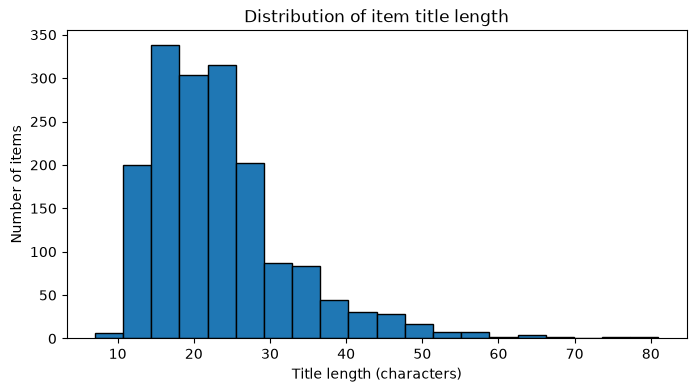

count    1682.00
mean       23.46
std         9.43
min         7.00
25%        17.00
50%        21.00
75%        27.00
max        81.00
Name: title, dtype: float64


In [9]:
def hist_title_length(items):
    # Given items dataframe, implement the function that generates a histogram of items title length. 
    # Hint: in histogram, x-axis shows the length of title, and y-axis shows the number of items with the corresponding length.

    ############# Your code here ############
    title_length = items['title'].fillna('').astype(str).str.len()

    plt.figure(figsize=(8, 4))
    plt.hist(title_length, bins=20, edgecolor='black')
    plt.xlabel('Title length (characters)')
    plt.ylabel('Number of items')
    plt.title('Distribution of item title length')
    plt.show()

    print(title_length.describe().round(2))
    #########################################
    
hist_title_length(items)

Discuss your observations.

Most of the titles are short. The median is 21 characters and three quarters of them fit inside 27, so the histogram piles up between roughly 11 and 29 characters and then trails off to the right.

That range makes sense once you look at the actual strings. A typical entry is a two or three word name plus the release year in brackets, and every single title carries that year. The tail running out to 81 characters is almost entirely foreign films that keep their original name next to the English one, like "Old Lady Who Walked in the Sea, The (Vieille qui marchait dans la mer, La) (1991)". At the other end there are a few nearly empty ones, including a film listed only as "unknown".

The thing to worry about for the rest of the assignment is that a title is a handful of tokens and one of them is a number. Whatever a title-based representation ends up encoding will come mostly from the genre string we concatenate onto it, plus whatever BERT already happens to know about famous film names.

### Question 4: Create the histogram of item description length. Set the number of bins to 20.

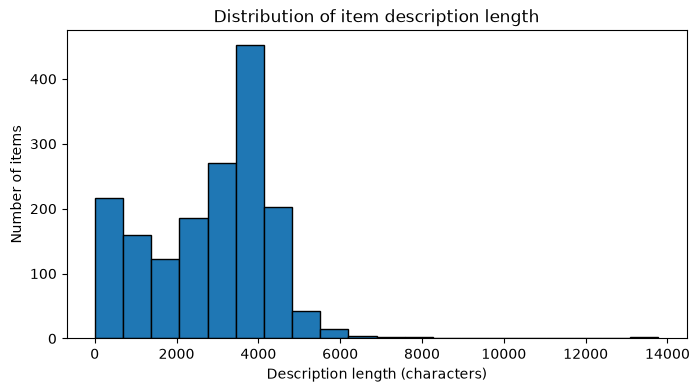

count     1682.00
mean      2853.02
std       1537.33
min          2.00
25%       1664.00
50%       3184.50
75%       3947.75
max      13779.00
Name: description, dtype: float64
Items with an empty description: 0


In [10]:
def hist_description_length(items):
    # Given items dataframe, implement the function that generates a histogram of items description length. 
    # Hint: in histogram, x-axis shows the length of description, and y-axis shows the number of items with the corresponding length.

    ############# Your code here ############
    description_length = items['description'].fillna('').astype(str).str.len()

    plt.figure(figsize=(8, 4))
    plt.hist(description_length, bins=20, edgecolor='black')
    plt.xlabel('Description length (characters)')
    plt.ylabel('Number of items')
    plt.title('Distribution of item description length')
    plt.show()

    print(description_length.describe().round(2))
    print(f"Items with an empty description: {(description_length == 0).sum()}")
    #########################################
    
hist_description_length(items)

Discuss your observations.

The descriptions are a different story. They run to about 2,850 characters on average, roughly 540 words, with a spread from 2 characters up to nearly 14,000.

The shape is not a single bell. Around 200 films have very short descriptions, 45 of them under 200 characters, and then the main mass sits between 3,000 and 4,000. A few enormous plot summaries stretch the axis so far that most of the right-hand bins come out empty, which makes the 20-bin histogram look sparser than the data actually is.

Two things follow from this. The description is by far the richest text available, so if BERT is going to contribute anything useful it will be here rather than in the titles. But DistilBERT stops reading at 512 tokens, and 1,126 of the 1,682 descriptions (67%) are longer than that, so for two thirds of the catalogue the model only ever sees the opening of the plot. The short descriptions have the opposite problem: a handful of words produces an embedding that is hard to distinguish from any other.

# 2) Deriving content representation with BERT

BERT (Bidirectional Encoder Representations from Transformers) provides rich, contextual embeddings that can capture semantic meaning. See [Devlin, Jacob, et al. "Bert: Pre-training of deep bidirectional transformers for language understanding." NAACL-HLT 2 2019](https://aclanthology.org/N19-1423.pdf) for more details.

In [11]:
def create_bert_embeddings(content):
    """
    Generate BERT embeddings for item content.

    Args:
        content: Content of items

    Returns:
        numpy.ndarray: BERT embeddings matrix
    """
    if not BERT_AVAILABLE:
        print("BERT libraries not available. Install with: pip install transformers torch")
        return None

    if content is None:
        return None

    if isinstance(content, pd.Series):
        content = content.fillna("").astype(str).tolist()
    elif isinstance(content, np.ndarray):
        content = content.astype(str).tolist()

    model_name = 'distilbert-base-uncased'

    print(f"Loading BERT model: {model_name}")

    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)

    # Set device (GPU if available)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using cuda or cpu: {device}")
    model.to(device)
    model.eval()

    print(f"Using device: {device}")

    # Generate embeddings in batches
    batch_size = 32  # Adjust based on available memory
    emb = []

    for i in range(0, len(content), batch_size):
        if i % (batch_size * 10) == 0:
            print(f"Processing batch {i//batch_size + 1}/{len(content)//batch_size + 1}")

        batch_texts = content[i:i + batch_size]

        # Tokenize batch
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )

        # Move to device
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Generate embeddings
        with torch.no_grad():
            outputs = model(**inputs)

            # Use [CLS] token embedding (first token)
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            emb.extend(batch_embeddings)

    emb = np.array(emb)

    print(f"BERT embeddings generated: {emb.shape}")
    print(f"Embedding dimension: {emb.shape[1]}")

    return emb

You can get the content representation using BERT as follows:

In [12]:
# Sample content
sample_content = ['aa','ab','ac','bc']

# Generate BERT embeddings (this may take several minutes)
print("Generating BERT embeddings...")
bert_embeddings = create_bert_embeddings(sample_content)

if bert_embeddings is not None:
    print("BERT embeddings created successfully!")
else:
    print("BERT embeddings not available. Continuing with TF-IDF only.")

Generating BERT embeddings...
Loading BERT model: distilbert-base-uncased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using cuda or cpu: cpu
Using device: cpu
Processing batch 1/1


BERT embeddings generated: (4, 768)
Embedding dimension: 768
BERT embeddings created successfully!


### Question 5: Derive the representation of items for three types of content: 
    1) title + category 
    2) description 
    3) title + category + description

In [13]:
# Implement code to derive the content representation for title and category. Concatenate the two content as: title + ' ' + category
item_emb_titlecategory = None
############# Your code here ############
item_emb_titlecategory = create_bert_embeddings(
    items['title'].fillna('') + ' ' + items['category'].fillna('')
)
#########################################

# Implement code to derive the content representation for description.
item_emb_description = None
############# Your code here ############
item_emb_description = create_bert_embeddings(items['description'].fillna(''))
#########################################

# Implement code to derive the content representation for title, category, and description. Concatenate the two content as: title + ' ' + category + '' + description
item_emb_full = None
############# Your code here ############
item_emb_full = create_bert_embeddings(
    items['title'].fillna('') + ' ' + items['category'].fillna('') + ' ' + items['description'].fillna('')
)
#########################################

Loading BERT model: distilbert-base-uncased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using cuda or cpu: cpu
Using device: cpu
Processing batch 1/53


Processing batch 11/53


...

Processing batch 21/53


Processing batch 31/53


Processing batch 41/53


Processing batch 51/53


BERT embeddings generated: (1682, 768)
Embedding dimension: 768


### Question 6: What is the embedding of item_id=100?

In [14]:
def get_item_emb(item_id, content_type):
    # Implement the function that given content type (title+category, description, or title+category+description) returns the embedding derived for the corresponding item_id. 
    # Hint1: keep in mind that item_id in the data starts from 1, but in the embedding variable it starts from 0, e.g., item_id 100 corresponds to index 99 in embedding variable..
    # Hint2: use if-else conditions to return the embedding for the requested content types.
    # Hint3: use the global variables (embeddings) already computed in previous cells.

    emb = None
    
    ############# Your code here ############
    # the template refers to the first content type both as 'title_category' and 'title_categroy'
    if content_type in ('title_category', 'title_categroy'):
        emb = item_emb_titlecategory[item_id - 1]
    elif content_type == 'description':
        emb = item_emb_description[item_id - 1]
    elif content_type == 'full':
        emb = item_emb_full[item_id - 1]
    else:
        raise ValueError(f'Unknown content type: {content_type}')
    #########################################

    return emb
    
item_id = 100
print('Embedding representation for content type = title+categroy:')
print(get_item_emb(item_id, 'title_category'))
print('------------------------------------------')
print('Embedding representation for content type = description:')
print(get_item_emb(item_id, 'description'))
print('------------------------------------------')
print('Embedding representation for content type = full:')
print(get_item_emb(item_id, 'full'))
print('------------------------------------------')

Embedding representation for content type = title+categroy:
[-1.33968741e-01 -9.01785493e-02 -1.27716631e-01 -1.31242558e-01
 -3.00812982e-02  1.16647147e-01  2.68211395e-01  1.28216326e-01
 -2.02164520e-02 -5.45810759e-02  1.50338784e-01 -5.03519848e-02
 -1.71943054e-01  3.98922563e-01  3.19538862e-01  3.08139890e-01
 -1.24051049e-01  3.27948749e-01  1.63815290e-01 -1.64276868e-01
 -1.18869230e-01 -2.46316731e-01  1.83683813e-01  9.05873626e-02
 -3.29117216e-02  1.50853515e-01 -3.94599319e-01 -9.15596262e-02
  1.46123588e-01  2.79693872e-01  2.88074166e-02  8.70801583e-02
 -1.64137393e-01 -6.84375465e-02  3.54835838e-01  1.68892220e-02
  1.22078240e-01 -1.09478429e-01 -5.38688004e-02 -8.63626152e-02
  2.87265200e-02  7.36704990e-02  2.03959182e-01 -1.56151637e-01
  8.09050053e-02 -8.71454775e-02 -2.65358377e+00 -2.31110856e-01
 -2.65956879e-01 -7.23349825e-02  2.97734559e-01  1.20156646e-01
  1.21809915e-01  1.11444362e-01  3.60954344e-01  5.76821506e-01
 -9.38287377e-02  8.00882205e-

# 3) User profile construction

### Question 7: What are the embeddings and ratings of interacted items by user_id=100?

In [15]:
def get_interacted_items_embs_rating(train_data, user_id, content_type):
    # Implement the function that given content type (title+categroy, description, or title+categroy+description) returns the embeddings and ratings of interacted items by user_id=100. 
    # Hint1: use train_data to retrieve the item_ids that target user (user_id=100 in this example) interacted, then pass these item_ids to function previously implemented to retrieve the embeddings and ratings.

    embs, ratings = [], []
    
    ############# Your code here ############
    user_interactions = train_data[train_data['user_id'] == user_id]
    for item_id, rating in zip(user_interactions['item_id'], user_interactions['rating']):
        embs.append(get_item_emb(item_id, content_type))
        ratings.append(rating)
    #########################################

    return embs, ratings
    
user_id = 100
print('Embeddings and ratings of interacted items by user_id=100 for content type = title+categroy:')
print(get_interacted_items_embs_rating(train_data, user_id, 'title_categroy'))
print('------------------------------------------')
print('Embeddings and ratings of interacted items by user_id=100 for content type = description:')
print(get_interacted_items_embs_rating(train_data, user_id, 'description'))
print('------------------------------------------')
print('Embeddings and ratings of interacted items by user_id=100 for content type = full:')
print(get_interacted_items_embs_rating(train_data, user_id, 'full'))
print('------------------------------------------')

Embeddings and ratings of interacted items by user_id=100 for content type = title+categroy:
([array([-9.96071696e-02, -7.49901757e-02, -1.20535076e-01, -2.76915103e-01,
       -5.08785844e-02,  1.03927359e-01,  2.32392043e-01,  1.92194074e-01,
       -2.33075470e-01, -7.28413314e-02,  5.68270683e-03, -7.94716775e-02,
       -7.75414035e-02,  3.07561725e-01,  2.68436730e-01,  1.68744177e-01,
       -4.06818092e-02,  2.00749278e-01,  1.42659932e-01, -2.60374814e-01,
       -2.01061606e-01, -1.63886130e-01,  1.07148506e-01,  4.95640971e-02,
       -5.44920228e-02,  1.81394994e-01, -1.69579834e-01, -2.86612883e-02,
        1.03714190e-01,  1.21496730e-01,  1.24387098e-02,  8.36618543e-02,
       -2.75053307e-02,  2.79795751e-02,  1.91911235e-01, -7.34995306e-02,
        1.14329323e-01,  2.60934308e-02, -1.05051398e-01,  8.60230252e-03,
        4.49391529e-02, -1.16302982e-01,  1.02928728e-01, -1.63409755e-01,
        1.00261644e-01, -1.27747208e-02, -2.26575565e+00, -7.43746385e-02,
     

### Question 8: Derive the representation for user_id=100 using the following aggregation methods:
1. **avg:** Average representation of interacted item 
2. **weighted_avg:** Weighted average representation of interacted item using rating values
3. **avg_pos:** Average representation of positively interacted item (ratings >= 4)

In [16]:
def get_user_emb(train_data, user_id, content_type, aggregation_method):
    # Implement the function that given content type (title+categroy, description, or title+categroy+description) and aggregation method (avg, weighted_avg, avg_pos) returns the representation of a user. 
    # Hint1: use the previsouly implemented items for retrieving ratings and representation of interacted items by a user.

    emb = []
    
    ############# Your code here ############
    embs, ratings = get_interacted_items_embs_rating(train_data, user_id, content_type)
    embs, ratings = np.array(embs), np.array(ratings, dtype=float)

    if aggregation_method == 'avg':
        emb = embs.mean(axis=0)
    elif aggregation_method == 'weighted_avg':
        emb = (ratings[:, None] * embs).sum(axis=0) / ratings.sum()
    elif aggregation_method == 'avg_pos':
        positive = ratings >= 4
        # a user without any positive rating falls back to the plain average
        emb = embs[positive].mean(axis=0) if positive.any() else embs.mean(axis=0)
    else:
        raise ValueError(f'Unknown aggregation method: {aggregation_method}')
    #########################################

    return emb
    
user_id = 100
content_type, aggregation_method = 'full', 'avg' # alternatives are content_type={title_categroy,description,full} and aggregation_method={avg,weighted_avg,avg_pos}
print('Embeddings of user_id=100 for content type '+content_type+' by aggregation method '+aggregation_method+':')
print(get_user_emb(train_data, user_id, content_type, aggregation_method))

Embeddings of user_id=100 for content type full by aggregation method avg:
[-3.87049973e-01 -1.66374862e-01 -2.16888309e-01 -2.51278460e-01
  1.98269188e-01  6.48261234e-02  3.83869648e-01  1.15339886e-02
 -4.22831217e-04 -2.02219173e-01 -1.02612108e-01  3.68849151e-02
 -1.85408488e-01  3.13278109e-01 -7.15674981e-02  1.79725885e-01
  1.60221055e-01  2.33235985e-01  1.77586272e-01 -6.24593459e-02
  4.65999357e-02 -2.32156634e-01  2.66273260e-01  3.56132299e-01
  9.99688637e-03  1.98544357e-02 -1.55338913e-01 -4.08473760e-02
 -3.74415033e-02  1.16085283e-01  1.31861359e-01  3.17430794e-02
 -4.82035950e-02 -4.34413493e-01  1.86724253e-02 -1.28039062e-01
  5.98856173e-02 -5.47315143e-02  7.34992772e-02  2.75155723e-01
 -7.57652381e-03  1.22199938e-01 -1.68472722e-01 -1.13499969e-01
  8.17911401e-02 -3.20805013e-01 -3.30789614e+00 -8.40353221e-02
 -8.25276598e-02 -1.85323566e-01  3.70509297e-01  2.29399398e-01
  1.46295696e-01  2.40077734e-01  3.30768675e-01  2.20875949e-01
 -3.72321635e-0

# 4) Content-based recommendation

Predict the rating for a user-item pair. Use dot product between user and item ebmeddings to predict the score.

### Question 9: What is the predicted score for user_id=100 and item_id=266?

**Note:** The predicted score might not be in the interval [1,5]. In the next part, after predicting the ratings for all user-item pair, the predictions will be normalized.

In [17]:
def get_user_item_prediction(train_data, user_id, item_id, content_type, aggregation_method):
    # Implement the function that given content type and aggregation method returns the predicted rating for a user-item pair. 
    # Hint1: use the previsouly implemented functions for retrieving the embeddings and then compute the dot product of user and item embeddings.

    pred_rating = 0.0
    
    ############# Your code here ############
    user_emb = get_user_emb(train_data, user_id, content_type, aggregation_method)
    item_emb = get_item_emb(item_id, content_type)
    pred_rating = float(np.dot(user_emb, item_emb))
    #########################################

    return pred_rating
    
user_id, item_id = 100, 266
content_type, aggregation_method = 'full', 'avg' # alternatives are content_type={title_categroy,description,full} and aggregation_method={avg,weighted_avg,avg_pos}
print('Predicted score for user_id=100 and item_id=266 for content type '+content_type+' and aggregation method '+aggregation_method+':')
print(get_user_item_prediction(train_data, user_id, item_id, content_type, aggregation_method))

Predicted score for user_id=100 and item_id=266 for content type full and aggregation method avg:
143.2740478515625


# 5) Metrics

For this part, refer to the lecture on "Evaluation of Recommender Systems" where different metrics are described.

### Question 10: Implement MAE, MSE, and RMSE for rating prediction task.

In [18]:
def MAE(actual_ratings, pred_ratings):
    # Implement a function that computes MAE error between actual ratings and predicted ratings. 
    # Note that actual_ratings and pred_ratings are lists.
    
    result = 0.0
    
    ############# Your code here ############
    actual, pred = np.asarray(actual_ratings, dtype=float), np.asarray(pred_ratings, dtype=float)
    result = float(np.mean(np.abs(actual - pred)))
    #########################################

    return result

def MSE(actual_rating, pred_rating):
    # Implement a function that computes MSE error between actual ratings and predicted ratings. 
    # Note that actual_ratings and pred_ratings are lists.
    
    result = 0.0
    
    ############# Your code here ############
    actual, pred = np.asarray(actual_rating, dtype=float), np.asarray(pred_rating, dtype=float)
    result = float(np.mean((actual - pred) ** 2))
    #########################################

    return result

def RMSE(actual_rating, pred_rating):
    # Implement a function that computes RMSE error between actual ratings and predicted ratings. 
    # Note that actual_ratings and pred_ratings are lists.
    
    result = 0.0
    
    ############# Your code here ############
    result = float(np.sqrt(MSE(actual_rating, pred_rating)))
    #########################################

    return result

### Question 11: Implement Precision and Recall.

In [19]:
def Precision(ground_truth, rec_list):
    # Implement a function that computes Precision across ground truth data and recommendation list generated for each user. 
    # Note that ground_truth and rec_list contain the list of items for all users, e.g., 2-dimensional arrays.
    
    result = 0.0
    
    ############# Your code here ############
    # precision of one user = |recommended and relevant| / |recommended|; report the mean over users
    per_user = []
    for gt, rec in zip(ground_truth, rec_list):
        if len(rec) == 0:
            continue
        hits = len(set(gt) & set(rec))
        per_user.append(hits / len(rec))
    result = float(np.mean(per_user)) if per_user else 0.0
    #########################################

    return result

def Recall(ground_truth, rec_list):
    # Implement a function that computes Recall across ground truth data and recommendation list generated for each user. 
    # Note that ground_truth and rec_list contain the list of items for all users, e.g., 2-dimensional arrays.
    
    result = 0.0
    
    ############# Your code here ############
    # recall of one user = |recommended and relevant| / |relevant|; users without test items are skipped
    per_user = []
    for gt, rec in zip(ground_truth, rec_list):
        if len(gt) == 0:
            continue
        hits = len(set(gt) & set(rec))
        per_user.append(hits / len(gt))
    result = float(np.mean(per_user)) if per_user else 0.0
    #########################################

    return result

# 6) Evaluation of content-based recommender for rating prediction task

### Question 12: Predict the ratings for all user-item pairs in test set and compute MAE, MSE, and RMSE. Discuss your observations.

In [20]:
def evaluate_rating_prediction(train_data, test_data, content_type, aggregation_method):
    # Implement a function that first computes the representation of users and then predicts the rating for each user-item pair. Finally, call the implemented metrics to measure the error.
    # Hint: the reason for pre-computing the representation of all users is to speed up the experiments and to avoid too many unnecessary computations.
    # Note: Make sure to map the predicted score into [1,5] interval. The prediction from content-based model may not necessarily be in 5-star rating scale.

    # here we compute the representation of users
    users_emb = []
    users = list(train_data['user_id'].unique())
    for user in tqdm(users):
        users_emb.append(get_user_emb(train_data, user, content_type, aggregation_method))

    print('Computing the representation of users is done!')

    actual_ratings, pred_ratings = [], []
    
    ############# Your code here ############
    # stack the pre-computed user profiles and the item embeddings, then score every test pair at once
    user_index = {user: idx for idx, user in enumerate(users)}
    users_emb = np.array(users_emb)
    item_emb_matrix = np.array([get_item_emb(item_id, content_type) for item_id in range(1, len(items) + 1)])

    u_idx = test_data['user_id'].map(user_index).values
    i_idx = test_data['item_id'].values - 1
    pred_ratings = np.sum(users_emb[u_idx] * item_emb_matrix[i_idx], axis=1)
    actual_ratings = test_data['rating'].values.astype(float)
    #########################################

    # Given predicted ratings, map them into [1,5] interval using -> 1 + (pred - min_val) * (4 / (max_val - min_val))
    ############# Your code here ############
    min_val, max_val = pred_ratings.min(), pred_ratings.max()
    pred_ratings = 1 + (pred_ratings - min_val) * (4 / (max_val - min_val))
    #########################################

    mae_value, mse_value, rmse_value = 0.0, 0.0, 0.0

    # compute the metrics: MAE, MSE, RMSE 
    ############# Your code here ############
    actual_ratings, pred_ratings = list(actual_ratings), list(pred_ratings)
    mae_value = MAE(actual_ratings, pred_ratings)
    mse_value = MSE(actual_ratings, pred_ratings)
    rmse_value = RMSE(actual_ratings, pred_ratings)
    #########################################

    return mae_value, mse_value, rmse_value

print('Performance of content-based recommender for content type = title+category and aggregation method = avg:')
mae_value, mse_value, rmse_value = evaluate_rating_prediction(train_data, test_data, 'title_category', 'avg')
print('MAE='+str(round(mae_value,5))+', MSE='+str(round(mse_value,5))+', RMSE='+str(round(rmse_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = description and aggregation method = avg:')
mae_value, mse_value, rmse_value = evaluate_rating_prediction(train_data, test_data, 'description', 'avg')
print('MAE='+str(round(mae_value,5))+', MSE='+str(round(mse_value,5))+', RMSE='+str(round(rmse_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = full and aggregation method = avg:')
mae_value, mse_value, rmse_value = evaluate_rating_prediction(train_data, test_data, 'full', 'avg')
print('MAE='+str(round(mae_value,5))+', MSE='+str(round(mse_value,5))+', RMSE='+str(round(rmse_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = title+category and aggregation method = weighted_avg:')
mae_value, mse_value, rmse_value = evaluate_rating_prediction(train_data, test_data, 'title_category', 'weighted_avg')
print('MAE='+str(round(mae_value,5))+', MSE='+str(round(mse_value,5))+', RMSE='+str(round(rmse_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = description and aggregation method = weighted_avg:')
mae_value, mse_value, rmse_value = evaluate_rating_prediction(train_data, test_data, 'description', 'weighted_avg')
print('MAE='+str(round(mae_value,5))+', MSE='+str(round(mse_value,5))+', RMSE='+str(round(rmse_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = full and aggregation method = weighted_avg:')
mae_value, mse_value, rmse_value = evaluate_rating_prediction(train_data, test_data, 'full', 'weighted_avg')
print('MAE='+str(round(mae_value,5))+', MSE='+str(round(mse_value,5))+', RMSE='+str(round(rmse_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = title+category and aggregation method = avg_pos:')
mae_value, mse_value, rmse_value = evaluate_rating_prediction(train_data, test_data, 'title_category', 'avg_pos')
print('MAE='+str(round(mae_value,5))+', MSE='+str(round(mse_value,5))+', RMSE='+str(round(rmse_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = description and aggregation method = avg_pos:')
mae_value, mse_value, rmse_value = evaluate_rating_prediction(train_data, test_data, 'description', 'avg_pos')
print('MAE='+str(round(mae_value,5))+', MSE='+str(round(mse_value,5))+', RMSE='+str(round(rmse_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = full and aggregation method = avg_pos:')
mae_value, mse_value, rmse_value = evaluate_rating_prediction(train_data, test_data, 'full', 'avg_pos')
print('MAE='+str(round(mae_value,5))+', MSE='+str(round(mse_value,5))+', RMSE='+str(round(rmse_value,5)))
print('------------------------------------------')

Performance of content-based recommender for content type = title+category and aggregation method = avg:


  0%|          | 0/943 [00:00<?, ?it/s]

 74%|███████▎  | 695/943 [00:00<00:00, 6944.64it/s]

100%|██████████| 943/943 [00:00<00:00, 6904.17it/s]

Computing the representation of users is done!
MAE=1.04629, MSE=1.76152, RMSE=1.32722
------------------------------------------
Performance of content-based recommender for content type = description and aggregation method = avg:


...

Computing the representation of users is done!
MAE=1.0035, MSE=1.47187, RMSE=1.21321
------------------------------------------
Performance of content-based recommender for content type = full and aggregation method = avg_pos:


  0%|          | 0/943 [00:00<?, ?it/s]

 74%|███████▍  | 697/943 [00:00<00:00, 6968.96it/s]

100%|██████████| 943/943 [00:00<00:00, 6906.61it/s]

Computing the representation of users is done!
MAE=0.9687, MSE=1.37946, RMSE=1.17451
------------------------------------------


Discuss your observations.

| content | aggregation | MAE | MSE | RMSE |
|---|---|---|---|---|
| title + category | avg | 1.046 | 1.762 | 1.327 |
| description | avg | 0.970 | 1.407 | 1.186 |
| full | avg | 0.953 | 1.373 | 1.172 |
| title + category | weighted_avg | 1.037 | 1.728 | 1.314 |
| description | weighted_avg | 0.972 | 1.406 | 1.186 |
| full | weighted_avg | 0.954 | 1.370 | 1.170 |
| title + category | avg_pos | 1.022 | 1.678 | 1.295 |
| description | avg_pos | 1.004 | 1.472 | 1.213 |
| full | avg_pos | 0.969 | 1.379 | 1.175 |

The content type matters and the aggregation method mostly does not. `full` comes out ahead for every aggregation at about 1.17 RMSE, `description` sits just behind it, and `title + category` is clearly the worst at around 1.30. That ordering is what the length histograms would predict, since a title plus a genre string gives the encoder almost nothing to work with.

Putting numbers on it: switching content type moves RMSE by 0.155, while switching aggregation moves it by at most 0.032 and by only 0.004 for `full`. The explanation seems to be that the raw DistilBERT `[CLS]` vectors are badly anisotropic. Every item vector has roughly the same norm, about 12.5, and two randomly picked movies already sit at 0.90 to 0.96 cosine similarity. Averaging a few dozen nearly parallel vectors lands you in almost the same direction whether you weight by rating or discard the low ratings entirely, so all three aggregation methods end up producing near-identical user profiles.

The more serious problem only showed up when I looked at the predictions themselves rather than the error metrics. The raw dot products all sit between about 140 and 150 with a standard deviation of roughly 4, and after the min-max mapping into [1,5] nearly everything lands in a narrow band around 3.4 to 3.9. The correlation between the normalised prediction and the actual rating is between −0.055 and +0.035 depending on content type, which is essentially zero. So the model is behaving like a constant predictor with noise added on top, and a genuinely constant predictor does better: predicting the global training mean of 3.53 for every pair gives RMSE 1.125, beating all nine content-based variants. `title + category` is worst precisely because its band is centred too high, near 3.9, and has the widest spread, so it piles noise on top of a bias.

It is worth being explicit about why the dot product fails here, since the assignment asks for it specifically. The dot product mixes two quantities: how well an item lines up with the user profile, which is the part we care about, and how long the item vector is, which is just an artefact of the encoder. Because the alignment term barely varies across items, the norm ends up dominating and the resulting ranking is nearly the same for every user. Switching to cosine similarity, mean-centring the embeddings before averaging, or fine-tuning the encoder on the rating task would each attack this from a different angle. The pre-trained `[CLS]` token was never trained to serve as a standalone sentence representation, and it shows.

### Question 13: Generate recommendation list of size 10 for each user and compute Precision and Recall. Discuss your observations.

In [21]:
def evaluate_topk_recommendation(train_data, test_data, content_type, aggregation_method):
    # Implement a function that first computes the representation of users and then predicts the relevance score of all items for each user. Next, return 10 unseen items with the highest predicted relevance score for each user as the recommendation list. Finally, call the implemented metrics to measure accuracy of recommendation.
    # Hint: the reason for pre-computing the representation of all users is to speed up the experiments and to avoid too many unnecessary computations.
    # Hint: no normalization is needed.

    # here we compute the representation of users
    users_emb = []
    users = list(train_data['user_id'].unique())
    for user in users:
        users_emb.append(get_user_emb(train_data, user, content_type, aggregation_method))

    ground_truth, rec_list = [], []
    
    ############# Your code here ############
    k = 10
    users_emb = np.array(users_emb)
    item_emb_matrix = np.array([get_item_emb(item_id, content_type) for item_id in range(1, len(items) + 1)])

    # relevance score of every item for every user in one matrix product: (n_users x n_items)
    scores = users_emb @ item_emb_matrix.T

    train_items_by_user = train_data.groupby('user_id')['item_id'].apply(set)
    test_items_by_user = test_data.groupby('user_id')['item_id'].apply(set)

    for idx, user in enumerate(users):
        # never recommend what the user already interacted with in the training data
        seen = np.array(sorted(train_items_by_user[user])) - 1
        scores[idx, seen] = -np.inf
        top_k = np.argsort(-scores[idx])[:k] + 1
        rec_list.append(list(top_k))
        ground_truth.append(list(test_items_by_user.get(user, set())))
    #########################################

    precision_value, recall_value = 0.0, 0.0

    # compute the metrics: Precision, Recall
    ############# Your code here ############
    precision_value = Precision(ground_truth, rec_list)
    recall_value = Recall(ground_truth, rec_list)
    #########################################

    return precision_value, recall_value

print('Performance of content-based recommender for content type = title+categroy and aggregation method = avg:')
precision_value, recall_value = evaluate_topk_recommendation(train_data, test_data, 'title_categroy', 'avg')
print('Precision='+str(round(precision_value,5))+', Recall='+str(round(recall_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = description and aggregation method = avg:')
precision_value, recall_value = evaluate_topk_recommendation(train_data, test_data, 'description', 'avg')
print('Precision='+str(round(precision_value,5))+', Recall='+str(round(recall_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = full and aggregation method = avg:')
precision_value, recall_value = evaluate_topk_recommendation(train_data, test_data, 'full', 'avg')
print('Precision='+str(round(precision_value,5))+', Recall='+str(round(recall_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = title+categroy and aggregation method = weighted_avg:')
precision_value, recall_value = evaluate_topk_recommendation(train_data, test_data, 'title_categroy', 'weighted_avg')
print('Precision='+str(round(precision_value,5))+', Recall='+str(round(recall_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = description and aggregation method = weighted_avg:')
precision_value, recall_value = evaluate_topk_recommendation(train_data, test_data, 'description', 'weighted_avg')
print('Precision='+str(round(precision_value,5))+', Recall='+str(round(recall_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = full and aggregation method = weighted_avg:')
precision_value, recall_value = evaluate_topk_recommendation(train_data, test_data, 'full', 'weighted_avg')
print('Precision='+str(round(precision_value,5))+', Recall='+str(round(recall_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = title+categroy and aggregation method = avg_pos:')
precision_value, recall_value = evaluate_topk_recommendation(train_data, test_data, 'title_categroy', 'avg_pos')
print('Precision='+str(round(precision_value,5))+', Recall='+str(round(recall_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = description and aggregation method = avg_pos:')
precision_value, recall_value = evaluate_topk_recommendation(train_data, test_data, 'description', 'avg_pos')
print('Precision='+str(round(precision_value,5))+', Recall='+str(round(recall_value,5)))
print('------------------------------------------')
print('Performance of content-based recommender for content type = full and aggregation method = avg_pos:')
precision_value, recall_value = evaluate_topk_recommendation(train_data, test_data, 'full', 'avg_pos')
print('Precision='+str(round(precision_value,5))+', Recall='+str(round(recall_value,5)))
print('------------------------------------------')

Performance of content-based recommender for content type = title+categroy and aggregation method = avg:


Precision=0.02386, Recall=0.00944
------------------------------------------
Performance of content-based recommender for content type = description and aggregation method = avg:


Precision=0.06713, Recall=0.0305
------------------------------------------
Performance of content-based recommender for content type = full and aggregation method = avg:


Precision=0.03181, Recall=0.0139
------------------------------------------
Performance of content-based recommender for content type = title+categroy and aggregation method = weighted_avg:


Precision=0.02418, Recall=0.0097
------------------------------------------
Performance of content-based recommender for content type = description and aggregation method = weighted_avg:


Precision=0.0667, Recall=0.03084
------------------------------------------
Performance of content-based recommender for content type = full and aggregation method = weighted_avg:


Precision=0.0334, Recall=0.0147
------------------------------------------
Performance of content-based recommender for content type = title+categroy and aggregation method = avg_pos:


Precision=0.0246, Recall=0.00988
------------------------------------------
Performance of content-based recommender for content type = description and aggregation method = avg_pos:


Precision=0.06585, Recall=0.03085
------------------------------------------
Performance of content-based recommender for content type = full and aggregation method = avg_pos:


Precision=0.03489, Recall=0.0156
------------------------------------------


Discuss your observations.

| content | aggregation | Precision@10 | Recall@10 |
|---|---|---|---|
| title + category | avg | 0.0239 | 0.0094 |
| description | avg | 0.0671 | 0.0305 |
| full | avg | 0.0318 | 0.0139 |
| title + category | weighted_avg | 0.0242 | 0.0097 |
| description | weighted_avg | 0.0667 | 0.0308 |
| full | weighted_avg | 0.0334 | 0.0147 |
| title + category | avg_pos | 0.0246 | 0.0099 |
| description | avg_pos | 0.0659 | 0.0309 |
| full | avg_pos | 0.0349 | 0.0156 |

Accuracy is poor everywhere. The best setup is `description`, and it only manages to put about 0.67 relevant items into each 10-item list while recovering roughly 3% of what a user actually rated in the test set. `full` does about half as well and `title + category` barely clears random guessing.

The surprising part is that `description` beats `full` here, when `full` was marginally the better choice for rating prediction. My first guess was that the 512-token truncation was to blame, on the theory that prepending the title and genre pushes some of the plot out of the window. The embeddings do not support that. The prefix is only 9 tokens at the median, and if truncation were the mechanism then the items being truncated should be the ones whose two representations diverge most. The opposite holds: the 556 films short enough that no truncation happens have a mean cosine of 0.991 between their `description` and `full` vectors, while the 1,126 truncated ones sit at 0.994. So the prefix is not displacing plot text in any way that matters. What it does instead is shift the `[CLS]` vector itself, which is dominated by whatever appears at the start of the sequence, and that happens for every item regardless of length.

Looking at what actually gets recommended explains the low numbers better than any of the metrics do. Because the user profiles are nearly parallel, the score matrix ranks items in almost the same order for everyone. Across all 943 users only 64 to 89 distinct items ever appear in a top-10 list, depending on the configuration, and the single most recommended item turns up in 85% to 93% of them. What I have built is effectively a non-personalised ranking driven by the geometry of the item vectors, with each user's already-seen items filtered out. Whether a given configuration scores well then comes down to whether those few dozen items happen to be ones people rated in the test set, which is why the three content types differ so much despite none of them being personalised.

The aggregation method is once again irrelevant, differing by fractions of a percentage point, for the same reason as in Question 12. Precision and recall also track each other closely here, since every user receives exactly 10 recommendations and holds about 21 test items on average, making recall roughly precision times 10 over 21.

# Extended experiments

### Question 14: Implement a baseline for rating prediction task that returns average rating of target item as the predicted rating. 

For example, for a user u and item i, the prediction is the average of ratings given to i in training data.

#### Evaluate the performance of this baseline in terms of MAE, MSE, RMSE, and compare it with the results in Question 12. 

In [22]:
def evaluate_item_avg_baseline(train_data, test_data):
    # Hint: no normalization is needed.
    
    actual_ratings, pred_ratings = [], []
    
    ############# Your code here ############
    item_mean = train_data.groupby('item_id')['rating'].mean()
    global_mean = train_data['rating'].mean()  # fallback for items that never appear in training

    actual_ratings = list(test_data['rating'].astype(float))
    pred_ratings = list(test_data['item_id'].map(item_mean).fillna(global_mean))
    #########################################

    mae_value, mse_value, rmse_value = 0.0, 0.0, 0.0

    # compute the metrics: MAE, MSE, RMSE 
    ############# Your code here ############
    mae_value = MAE(actual_ratings, pred_ratings)
    mse_value = MSE(actual_ratings, pred_ratings)
    rmse_value = RMSE(actual_ratings, pred_ratings)
    #########################################

    return mae_value, mse_value, rmse_value

print('Performance of the item-average baseline for rating prediction:')
mae_value, mse_value, rmse_value = evaluate_item_avg_baseline(train_data, test_data)
print('MAE='+str(round(mae_value,5))+', MSE='+str(round(mse_value,5))+', RMSE='+str(round(rmse_value,5)))


Performance of the item-average baseline for rating prediction:
MAE=0.81012, MSE=1.04143, RMSE=1.02051


Discuss your observations:

The item-average baseline gives MAE 0.810, MSE 1.041 and RMSE 1.021. Twenty-seven items in the test set never appear in training, and those fall back to the global mean.

This is a trivial model and it beats every content-based configuration from Question 12 comfortably, 1.021 against 1.170 on RMSE and 0.810 against 0.953 on MAE. It also clears the constant global-mean predictor at 1.125, which the content-based models did not manage.

What it is picking up is item bias. The single largest source of variance in MovieLens ratings is that some films are simply rated higher than others by nearly everyone, and the item average reads that straight off the ratings. The content-based model has no access to it. All it sees is text, and as Question 12 showed, its dot-product scores are barely correlated with the ratings at all. This is the standard limitation of pure content-based filtering: it can tell you that two films are about similar things, but it has no way to know that one of them is better. Anything practical would combine the two, whether by adding item and user biases on top of the content score or by learning a mapping from the embedding to the rating instead of taking the raw dot product.

### Question 15: Implement the following baselines for ranking task:

**Random:** Randomly recommend 10 unseen items (items not interacted by the target user in training data) to each user

**Popular:** Recommend 10 most popular items that are not yet interacted by the target user. Most popular items are the ones that are rated by majority of users in the training data.

#### Evaluate the performance of these baselines in terms of Precision and Recall, and compare them with the results in Question 13. 

In [23]:
def evaluate_random_baseline(train_data, test_data):
    # Hint: no normalization is needed.
    
    ground_truth, rec_list = [], []
    
    ############# Your code here ############
    rng = np.random.default_rng(42)
    all_items = np.arange(1, len(items) + 1)
    train_items_by_user = train_data.groupby('user_id')['item_id'].apply(set)
    test_items_by_user = test_data.groupby('user_id')['item_id'].apply(set)

    for user in train_data['user_id'].unique():
        unseen = np.array([item for item in all_items if item not in train_items_by_user[user]])
        rec_list.append(list(rng.choice(unseen, size=10, replace=False)))
        ground_truth.append(list(test_items_by_user.get(user, set())))
    #########################################

    precision_value, recall_value = 0.0, 0.0

    # compute the metrics: Precision, Recall
    ############# Your code here ############
    precision_value = Precision(ground_truth, rec_list)
    recall_value = Recall(ground_truth, rec_list)
    #########################################

    return precision_value, recall_value

In [24]:
def evaluate_popular_baseline(train_data, test_data):
    # Hint: no normalization is needed.
    
    ground_truth, rec_list = [], []
    
    ############# Your code here ############
    # popularity = number of training users who rated the item, most popular first
    popular_items = list(train_data['item_id'].value_counts().index)
    train_items_by_user = train_data.groupby('user_id')['item_id'].apply(set)
    test_items_by_user = test_data.groupby('user_id')['item_id'].apply(set)

    for user in train_data['user_id'].unique():
        seen = train_items_by_user[user]
        rec_list.append([item for item in popular_items if item not in seen][:10])
        ground_truth.append(list(test_items_by_user.get(user, set())))
    #########################################

    precision_value, recall_value = 0.0, 0.0

    # compute the metrics: Precision, Recall
    ############# Your code here ############
    precision_value = Precision(ground_truth, rec_list)
    recall_value = Recall(ground_truth, rec_list)
    #########################################

    return precision_value, recall_value

print('Performance of the random baseline for top-10 recommendation:')
precision_value, recall_value = evaluate_random_baseline(train_data, test_data)
print('Precision='+str(round(precision_value,5))+', Recall='+str(round(recall_value,5)))
print('------------------------------------------')
print('Performance of the popularity baseline for top-10 recommendation:')
precision_value, recall_value = evaluate_popular_baseline(train_data, test_data)
print('Precision='+str(round(precision_value,5))+', Recall='+str(round(recall_value,5)))


Performance of the random baseline for top-10 recommendation:
Precision=0.01326, Recall=0.0062
------------------------------------------
Performance of the popularity baseline for top-10 recommendation:


Precision=0.19809, Recall=0.11449


Discuss your observations:

Random gives Precision@10 0.0133 and Recall@10 0.0062. Popularity gives 0.1981 and 0.1145.

Random is the floor and it is exactly where the arithmetic says it should be: about 21 test items among roughly 1,600 candidates works out to 1.3%. The uncomfortable part is how close `title + category` gets to it, at 2.4%, which is less than twice random. Even the best content-based configuration at 6.7% is only about five times random.

Popularity is in a different league. Recommending the ten most-rated training films a user has not already seen, which turns out to be Star Wars, Return of the Jedi, Contact and Fargo among others, gives roughly three times the precision of the best content-based setup and about fifteen times random. This is a known quirk of MovieLens: the ratings concentrate heavily on a few hundred well-known films, and since the test split is a random sample of those same ratings, it is dominated by the same titles. A popularity ranking exploits that directly. Given that the content-based model also collapses into a near-identical list for every user, the honest comparison is between two non-personalised rankings, one ordered by something users actually did and one ordered by an artefact of a text encoder.

None of which means content-based methods are useless, just that accuracy on a dataset like this is the wrong place to look for their value. They earn their keep when the collaborative signal is missing: brand new items with no ratings, thin or niche catalogues, and explanations a user can actually follow, as in "because you watched". To compete on raw accuracy the representation would need to be adapted to the task rather than taken frozen off the shelf, and it would want the collaborative signal that the popularity and item-average baselines pick up almost for free.